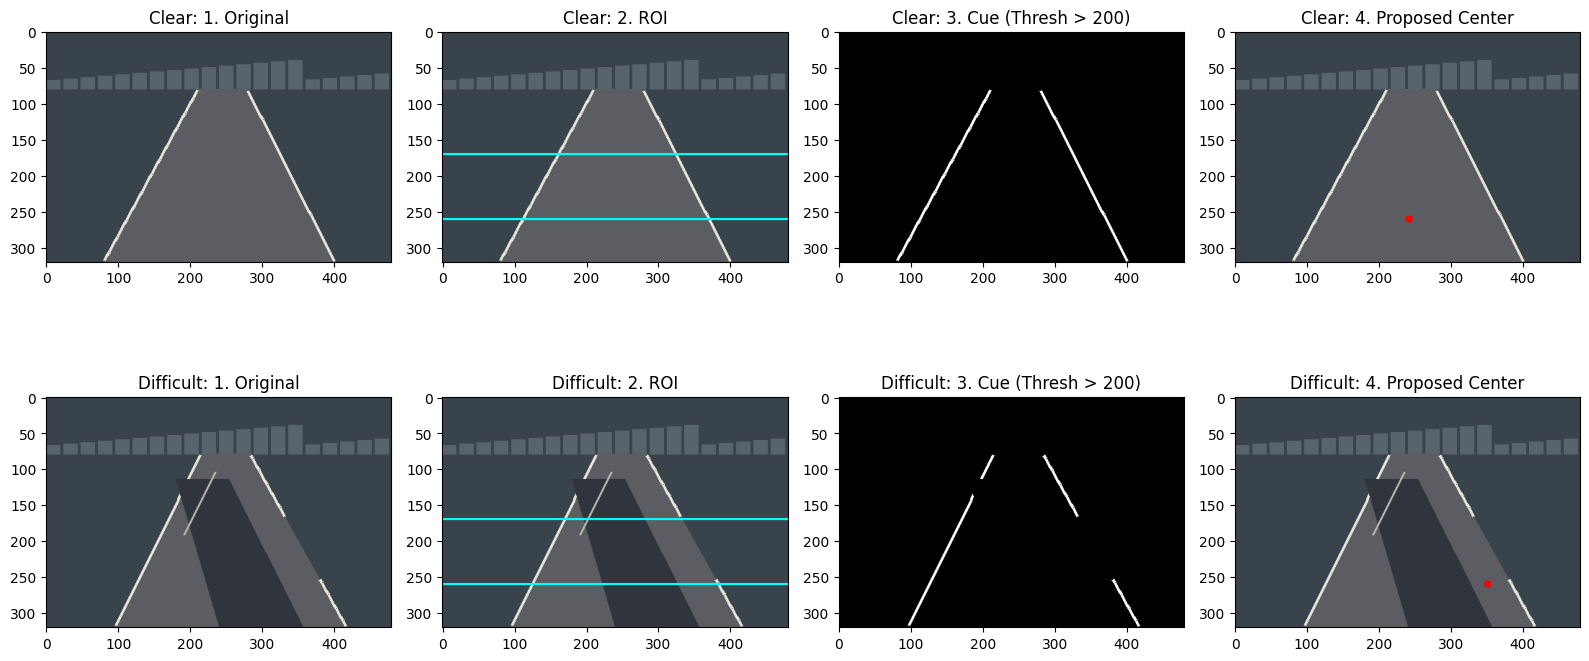

In [11]:
import cv2
import matplotlib.pyplot as plt

def generate_panel(clear_path, difficult_path):
    # Load images
    img_clear = cv2.imread(clear_path)
    img_diff = cv2.imread(difficult_path)
    
    # Create the figure grid (2 rows, 4 columns)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Process both images in a loop
    for idx, (img_bgr, title_prefix) in enumerate([(img_clear, "Clear"), (img_diff, "Difficult")]):
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        # 1. Original
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"{title_prefix}: 1. Original")
        
        # 2. ROI (Highlighting rows 170 and 260)
        roi_img = img_rgb.copy()
        cv2.line(roi_img, (0, 170), (479, 170), (0, 255, 255), 2)
        cv2.line(roi_img, (0, 260), (479, 260), (0, 255, 255), 2)
        axes[idx, 1].imshow(roi_img)
        axes[idx, 1].set_title(f"{title_prefix}: 2. ROI")
        
        # 3. Extracted Cue (Baseline Threshold)
        _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
        axes[idx, 2].imshow(thresh, cmap='gray')
        axes[idx, 2].set_title(f"{title_prefix}: 3. Cue (Thresh > 200)")
        
        # 4. Proposed Center (You would plug your actual u_n, u_f variables here)
        # For visualization, we'll just plot dummy dots where it might guess
        output = img_rgb.copy()
        if title_prefix == "Clear":
            cv2.circle(output, (241, 260), 5, (255, 0, 0), -1) # Blue dot for center
        else:
            cv2.circle(output, (350, 260), 5, (255, 0, 0), -1) # Wrong center
            
        axes[idx, 3].imshow(output)
        axes[idx, 3].set_title(f"{title_prefix}: 4. Proposed Center")

    plt.tight_layout()
    plt.show()

# Run it on your frames
generate_panel(
    r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/clear/000.png", 
    r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/missing/015.png"
)

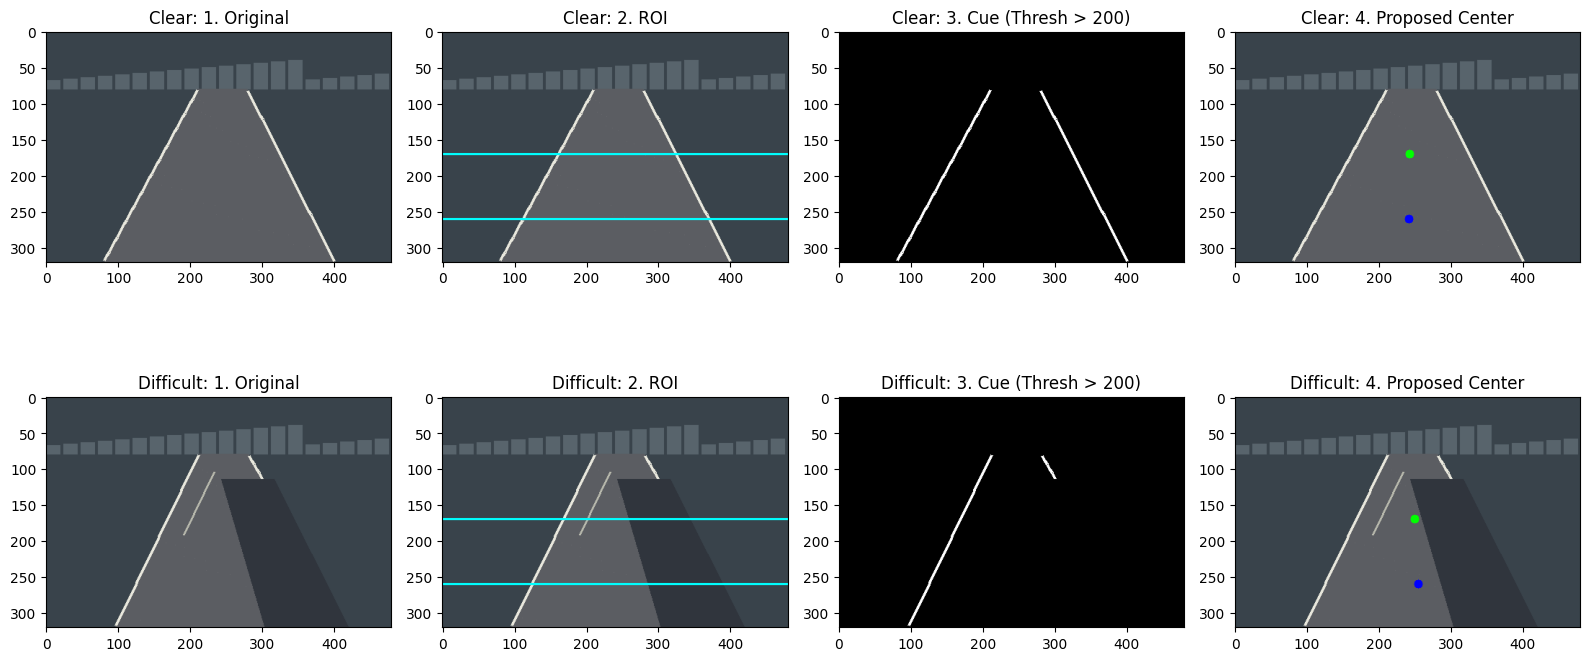

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Bring in your actual baseline logic!
def find_lane_centers(image):
    threshold_value = 200
    expected_width_near = 258  
    expected_width_far = 163   
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
    
    def process_row(row_pixels, expected_width):
        white_indices = np.where(row_pixels == 255)[0]
        left_pixels = white_indices[white_indices < 240]
        right_pixels = white_indices[white_indices >= 240]
        
        u_left = int(np.mean(left_pixels)) if len(left_pixels) > 0 else None
        u_right = int(np.mean(right_pixels)) if len(right_pixels) > 0 else None
            
        if u_left is not None and u_right is not None:
            return int((u_left + u_right) / 2)
        elif u_left is not None:
            return int(u_left + (expected_width / 2))
        elif u_right is not None:
            return int(u_right - (expected_width / 2))
        else:
            return None

    u_n = process_row(thresh[260, :], expected_width_near)
    u_f = process_row(thresh[170, :], expected_width_far)
    return u_n, u_f

# 2. The Panel Generator
def generate_panel(clear_path, difficult_path):
    img_clear = cv2.imread(clear_path)
    img_diff = cv2.imread(difficult_path)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for idx, (img_bgr, title_prefix) in enumerate([(img_clear, "Clear"), (img_diff, "Difficult")]):
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        # 1. Original
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"{title_prefix}: 1. Original")
        
        # 2. ROI
        roi_img = img_rgb.copy()
        cv2.line(roi_img, (0, 170), (479, 170), (0, 255, 255), 2)
        cv2.line(roi_img, (0, 260), (479, 260), (0, 255, 255), 2)
        axes[idx, 1].imshow(roi_img)
        axes[idx, 1].set_title(f"{title_prefix}: 2. ROI")
        
        # 3. Cue
        _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
        axes[idx, 2].imshow(thresh, cmap='gray')
        axes[idx, 2].set_title(f"{title_prefix}: 3. Cue (Thresh > 200)")
        
        # 4. Proposed Center (USING REAL DATA NOW)
        output = img_rgb.copy()
        u_n, u_f = find_lane_centers(img_bgr)
        
        # Plot Near Row Center (Blue Dot)
        if u_n is not None:
            cv2.circle(output, (u_n, 260), 6, (0, 0, 255), -1) # Blue in RGB
            
        # Plot Far Row Center (Green Dot)
        if u_f is not None:
            cv2.circle(output, (u_f, 170), 6, (0, 255, 0), -1) # Green in RGB
            
        axes[idx, 3].imshow(output)
        axes[idx, 3].set_title(f"{title_prefix}: 4. Proposed Center")

    plt.tight_layout()
    plt.show()

# Replace these paths with your actual local file paths
generate_panel(
   r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/clear/000.png", 
   r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/missing/022.png"
)

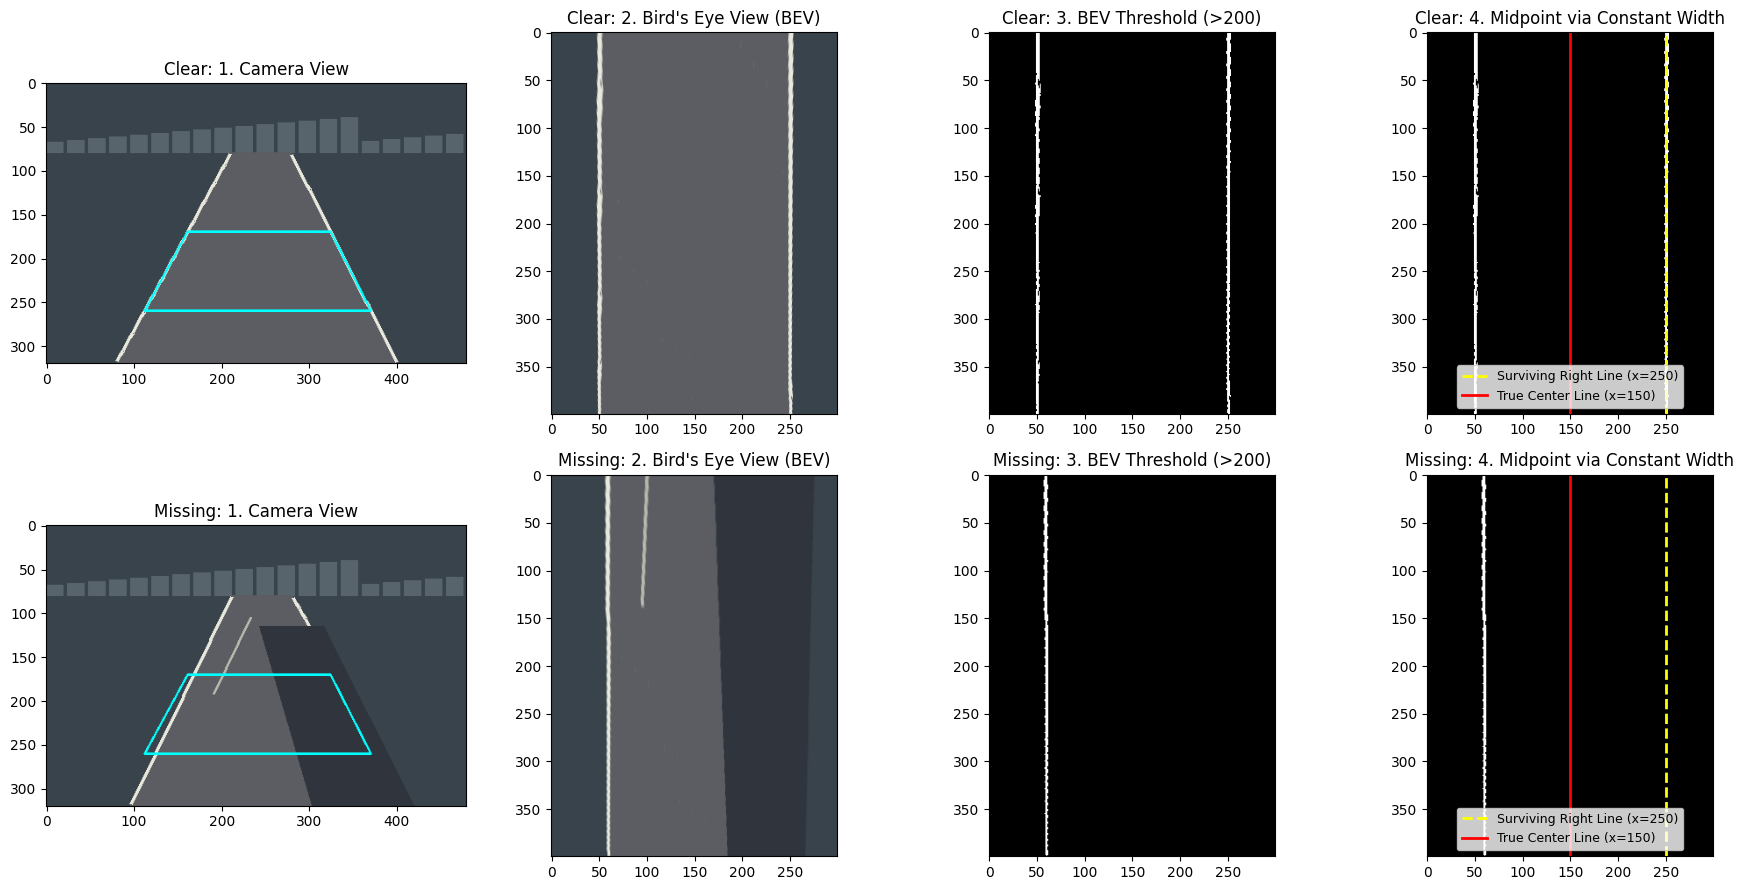

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_bev_panel(clear_path, difficult_path):
    # Load the images
    img_clear = cv2.imread(clear_path)
    img_diff = cv2.imread(difficult_path)
    
    # 1. The Perspective Transform Matrix (The Geometry Extension)
    # These are the exact pixel locations of the lane lines we measured earlier
    src_points = np.float32([
        [161, 170],  # Top-Left (Far Row)
        [324, 170],  # Top-Right (Far Row)
        [370, 260],  # Bottom-Right (Near Row)
        [112, 260]   # Bottom-Left (Near Row)
    ])

    # We will warp that trapezoid into a perfect rectangle (300x400 map)
    map_w, map_h = 300, 400
    
    # We will force the lane to be exactly 200 pixels wide in the Bird's Eye View
    # Left line at x=50, Right line at x=250.
    dst_points = np.float32([
        [50, 0],             # Top-Left mapped
        [250, 0],            # Top-Right mapped
        [250, map_h],        # Bottom-Right mapped
        [50, map_h]          # Bottom-Left mapped
    ])

    # Calculate the mathematical transformation matrix
    matrix = cv2.getPerspectiveTransform(src_points, dst_points)

    # 2. Setup the Plotting Panel (2 rows, 4 columns)
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    for idx, (img_bgr, title_prefix) in enumerate([(img_clear, "Clear"), (img_diff, "Missing")]):
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        # --- GRAPH 1: Original with Perspective Region ---
        orig_vis = img_rgb.copy()
        pts = src_points.reshape((-1, 1, 2)).astype(np.int32)
        cv2.polylines(orig_vis, [pts], True, (0, 255, 255), 2) # Draw yellow trapezoid
        axes[idx, 0].imshow(orig_vis)
        axes[idx, 0].set_title(f"{title_prefix}: 1. Camera View")

        # --- GRAPH 2: Bird's Eye View (RGB) ---
        bev_rgb = cv2.warpPerspective(img_rgb, matrix, (map_w, map_h))
        axes[idx, 1].imshow(bev_rgb)
        axes[idx, 1].set_title(f"{title_prefix}: 2. Bird's Eye View (BEV)")

        # --- GRAPH 3: BEV Threshold (The Cue) ---
        bev_gray = cv2.warpPerspective(gray, matrix, (map_w, map_h))
        _, bev_thresh = cv2.threshold(bev_gray, 200, 255, cv2.THRESH_BINARY)
        axes[idx, 2].imshow(bev_thresh, cmap='gray')
        axes[idx, 2].set_title(f"{title_prefix}: 3. BEV Threshold (>200)")

        # --- GRAPH 4: Midpoint from Known Width ---
        # Convert binary image back to RGB so we can draw colored lines on it
        out_vis = cv2.cvtColor(bev_thresh, cv2.COLOR_GRAY2RGB)
        
        axes[idx, 3].imshow(out_vis)
        
        # In BEV, the surviving right line is always perfectly straight at x=250.
        axes[idx, 3].axvline(x=250, color='yellow', linestyle='--', linewidth=2, label='Surviving Right Line (x=250)')
        
        # Since we forced the road to be 200px wide everywhere, the true center is ALWAYS at x=150.
        # Even when the left line is missing in the shadow, 250 - (200/2) = 150.
        axes[idx, 3].axvline(x=150, color='red', linestyle='-', linewidth=2, label='True Center Line (x=150)')
        
        axes[idx, 3].set_title(f"{title_prefix}: 4. Midpoint via Constant Width")
        axes[idx, 3].legend(loc='lower center', fontsize=9)

    plt.tight_layout()
    plt.show()

# Replace these paths with your actual local file paths
generate_bev_panel(
   r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/clear/000.png", 
   r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/missing/022.png"
)